# 01 Strategy Baseline

\This notebook runs the default baseline strategy and verifies that portfolio behavior (equity, drawdown, exposures, turnover) matches expectations.

### Expected
- Stable execution with no NaN equity values.
- Gross exposure near target/caps and net exposure consistent with hedge ratio + tilt.
- Pair-level performance differences (QQQ/TQQQ typically steadier than BTC/BITX).


In [13]:
# Standard notebook bootstrap.
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.experiments.run_baseline import run as run_baseline
from src.utils.io import load_config


## Run Controls
- Change `CONFIG_PATH` to run a pair-specific config (`btc_bitx.yaml` or `qqq_tqqq.yaml`).
- If this cell fails with data errors, run `00_data_sanity.ipynb` first.


In [14]:
CONFIG_PATH = ROOT / "configs" / "default.yaml"
cfg = load_config(CONFIG_PATH)

# run_baseline executes the pipeline and writes figures/tables under reports/.
backtests = run_baseline(str(CONFIG_PATH))
print("Backtests generated for:", list(backtests.keys()))


Backtests generated for: ['btc_bitx', 'qqq_tqqq']


In [15]:
# Baseline summary metrics are persisted by the runner.
metrics_path = ROOT / "reports" / "tables" / "baseline_metrics.csv"
metrics = pd.read_csv(metrics_path, index_col=0)
metrics.sort_values("sharpe", ascending=False)


,cagr,vol,sharpe,sortino,max_drawdown,calmar,skew,kurtosis,hit_rate,cvar_95,downside_vol,total_return
qqq_tqqq,0.016066,0.005562,2.868288,4.705584,-0.003207,5.008840,2.870782,38.211989,0.584832,-0.000658,0.003390,0.084254
btc_bitx,0.035273,0.187215,0.278633,0.379255,-0.115400,0.305656,0.106670,5.497922,0.517052,-0.027667,0.137544,0.133195


## Interpreting Metrics
- `cagr` and `sharpe` summarize return quality.
- `max_drawdown` captures tail pain in realized paths.
- `hit_rate` is directional consistency, not magnitude-adjusted quality.


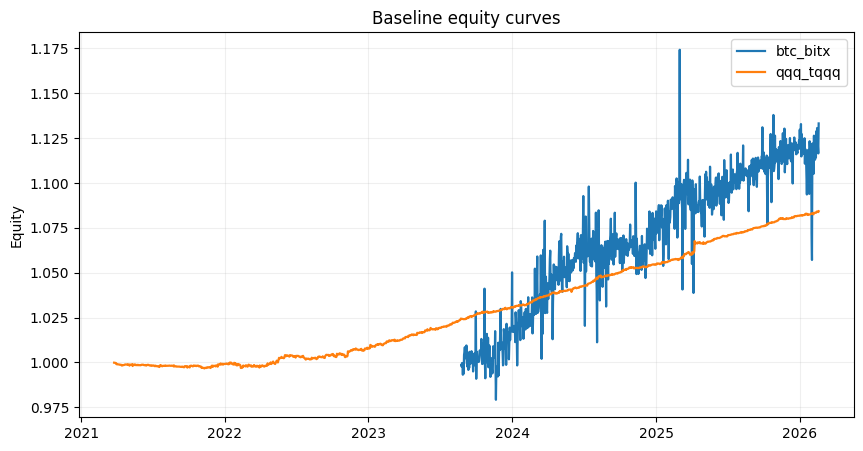

In [16]:
# Compare equity curves across pairs in one frame.
fig, ax = plt.subplots(figsize=(10, 5))
for name, bt in backtests.items():
    ax.plot(bt.index, bt["equity"], label=name, lw=1.6)
ax.set_title("Baseline equity curves")
ax.set_ylabel("Equity")
ax.grid(alpha=0.2)
ax.legend()
plt.show()


### Gross vs Net Exposure
- `gross = |w_spot| + |w_lev|` is total deployed notional.
- `net = w_spot + w_lev` is directional bias.
- With weekly rebalance + threshold trigger, gross should stay near target while net drifts with hedge ratio changes.


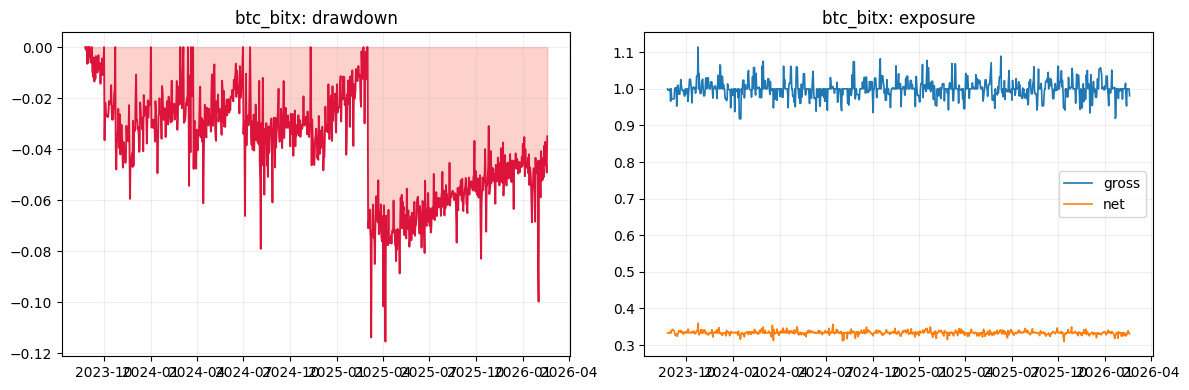

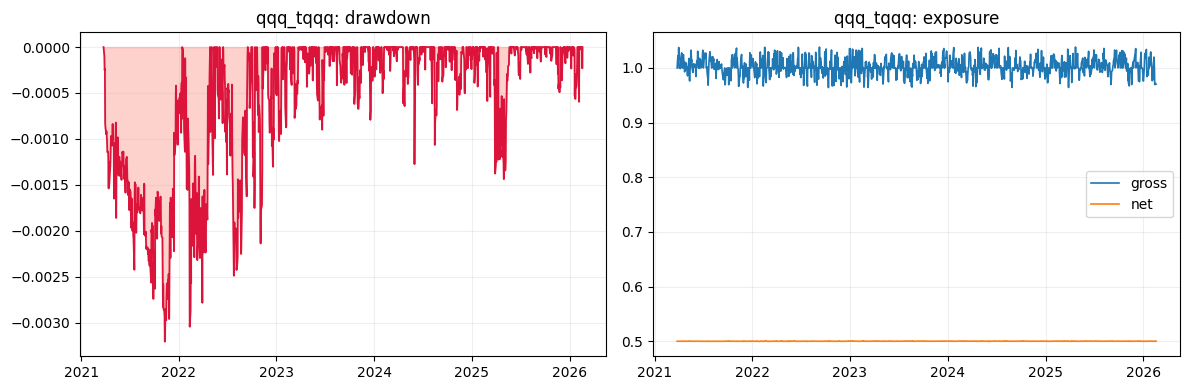

In [17]:
# Pair-level diagnostics: drawdown and exposure profile.
for name, bt in backtests.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(bt.index, bt["drawdown"], color="crimson", lw=1.3)
    axes[0].fill_between(bt.index, bt["drawdown"], 0, color="salmon", alpha=0.35)
    axes[0].set_title(f"{name}: drawdown")
    axes[0].grid(alpha=0.2)

    axes[1].plot(bt.index, bt["gross"], label="gross", lw=1.2)
    axes[1].plot(bt.index, bt["net"], label="net", lw=1.2)
    axes[1].set_title(f"{name}: exposure")
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


In [18]:
# Turnover gives a direct read on transaction-cost pressure.
turnover_stats = {}
for name, bt in backtests.items():
    turnover_stats[name] = {
        "avg_turnover": float(bt["turnover"].mean()),
        "p95_turnover": float(bt["turnover"].quantile(0.95)),
        "rebalance_count": int((bt["turnover"] > 0).sum()),
    }
pd.DataFrame(turnover_stats).T


,avg_turnover,p95_turnover,rebalance_count
btc_bitx,0.016644,0.088726,250.0
qqq_tqqq,0.009622,0.051071,330.0


In [19]:
# Basic invariants: fail fast if execution behavior is invalid.
max_gross = float(cfg["strategy"].get("max_gross", 1.5))
for name, bt in backtests.items():
    assert bt["equity"].notna().all(), f"{name}: NaN in equity"
    assert (bt["equity"] > 0).all(), f"{name}: non-positive equity"
    assert (bt["turnover"] >= 0).all(), f"{name}: negative turnover"
    assert (bt["gross"] <= max_gross + 1e-8).all(), f"{name}: max_gross violated"

print("Baseline invariants passed.")


Baseline invariants passed.


## Next Notebook
Move to `02_regime_maps.ipynb` to understand where the strategy makes and loses money across drift/volatility conditions.
